# Traffic Light Classifier
## 1. Import Libraries and Define Constants

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Constants
IMG_HEIGHT, IMG_WIDTH = 64, 64
BATCH_SIZE = 32
BASE_DIR = 'traffic' # Assuming 'traffic' folder is in the same directory

print("Libraries imported and constants defined.")

d:\UK\Coursework-item2-20251219\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Libraries imported and constants defined.


## 2. Data Loading and Exploration

Sample Images:


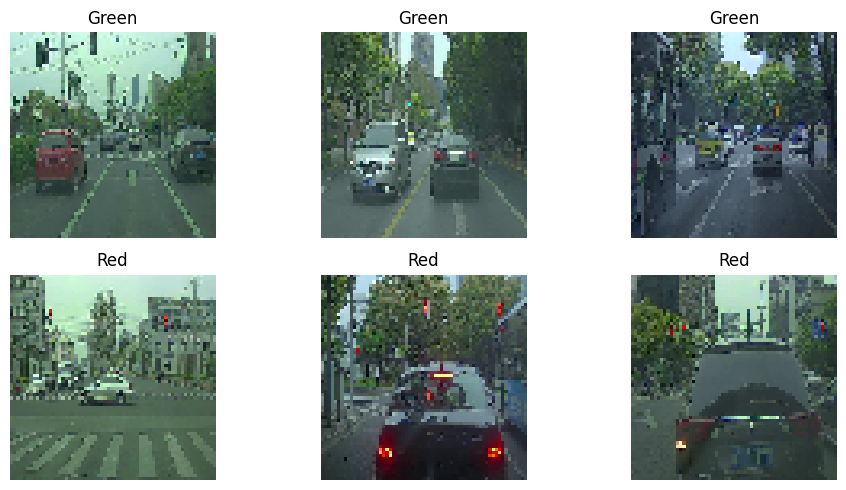

In [2]:
# Function to display sample images
def display_samples(base_path, num_samples=3):
    classes = ['Green', 'Red']
    plt.figure(figsize=(10, 5))
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(base_path, class_name)
        if not os.path.exists(class_path):
            print(f"Directory {class_path} not found.")
            continue
            
        images = os.listdir(class_path)
        # Filter for image files just in case
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for j in range(min(num_samples, len(images))):
            img_path = os.path.join(class_path, images[j])
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            
            plt.subplot(2, num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

print("Sample Images:")
display_samples(BASE_DIR)

## 3. Data Preprocessing and Augmentation

In [3]:
# Data Augmentation and Normalization
# Using validation_split to create Train (80%) and Validation (20%) sets
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    validation_split=0.2
)

print("Training Generator:")
train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

print("Validation Generator:")
validation_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False # Important for evaluation metrics later
)

print(f"Class indices: {train_generator.class_indices}")

Training Generator:
Found 160 images belonging to 2 classes.
Validation Generator:
Found 40 images belonging to 2 classes.
Class indices: {'Green': 0, 'Red': 1}


## 4. Build the Baseline CNN Model

In [4]:
def build_baseline_model():
    model = Sequential([
        # First Conv Block
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        MaxPooling2D(2, 2),
        
        # Second Conv Block
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Flatten and Dense
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

d:\UK\Coursework-item2-20251219\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,337 (3.14 MB)

 Trainable params: 822,337 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Baseline Model

In [5]:
EPOCHS = 15

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 575ms/step - accuracy: 0.5312 - loss: 0.7999 - precision: 0.5221 - recall: 0.7375 - val_accuracy: 0.5000 - val_loss: 0.7100 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - accuracy: 0.5625 - loss: 0.6859 - precision: 0.5676 - recall: 0.5250 - val_accuracy: 0.5000 - val_loss: 0.6897 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step - accuracy: 0.5750 - loss: 0.6861 - precision: 0.5968 - recall: 0.4625 - val_accuracy: 0.4750 - val_loss: 0.6916 - val_precision: 0.4872 - val_recall: 0.9500
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 0.5188 - loss: 0.6877 - precision: 0.5102 - recall: 0.9375 - val_accuracy: 0.4500 - val_loss: 0.6897 - val_precision: 0.4722 - val_recall: 0.8500
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.6625 - loss: 0.6716 - precision: 0.6327 - recall: 0.7750 - val_accuracy: 0.5000 - val_loss: 0.69

## 6. Evaluate Model Performance

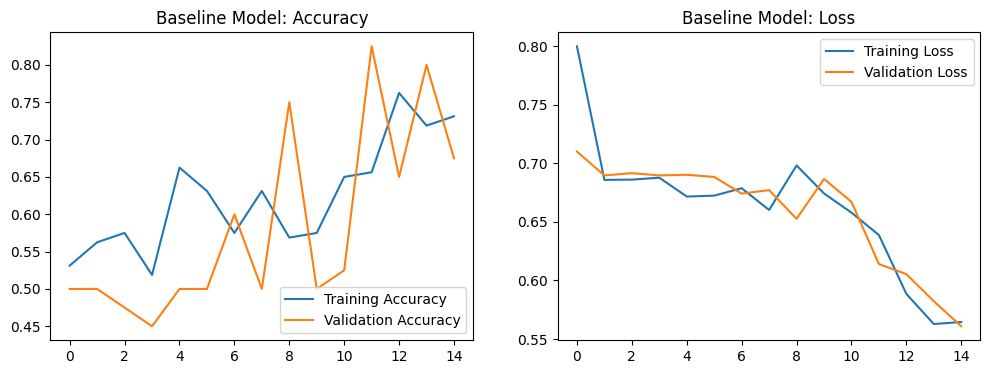

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7500 - loss: 0.5703 - precision: 0.6923 - recall: 0.9000
Test Accuracy: 75.00%
Precision: 0.6923
Recall: 0.9000


In [6]:
# Plotting results
def plot_history(history, title="Model Performance"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title}: Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title}: Loss')
    plt.show()

plot_history(history_baseline, title="Baseline Model")

# Evaluate on validation set
loss, accuracy, precision, recall = baseline_model.evaluate(validation_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

## 7. External Testing with New Images

In [7]:
# Placeholder for external testing
# Note: To use this, place 5 images in a folder named 'test_images' or update the path.
# Since we don't have external images downloaded, this code is a template.

from tensorflow.keras.preprocessing import image

def predict_external_image(model, img_path):
    try:
        img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0
        
        prediction = model.predict(img_array, verbose=0)
        # Check class indices: {'Green': 0, 'Red': 1}
        label = "Red" if prediction[0][0] >= 0.5 else "Green"
        confidence = prediction[0][0] if prediction[0][0] >= 0.5 else 1 - prediction[0][0]
        
        plt.imshow(img)
        plt.title(f"Predicted: {label} ({confidence:.2f})")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Could not load image {img_path}: {e}")

# Example usage (uncomment if you have images)
# external_images_dir = 'test_images'
# if os.path.exists(external_images_dir):
#     for img_file in os.listdir(external_images_dir):
#         predict_external_image(baseline_model, os.path.join(external_images_dir, img_file))
# else:
#     print("No 'test_images' directory found. Please add images to test.")

## 8. Model Improvement Strategy 1: Enhanced Augmentation

Training Improved Model (More Augmentation)...
Found 160 images belonging to 2 classes.
Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - accuracy: 0.5562 - loss: 0.6946 - precision: 0.5556 - recall: 0.5625 - val_accuracy: 0.5000 - val_loss: 0.7006 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.5188 - loss: 0.7027 - precision: 0.5211 - recall: 0.4625 - val_accuracy: 0.5000 - val_loss: 0.6925 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step - accuracy: 0.5312 - loss: 0.6883 - precision: 0.5194 - recall: 0.8375 - val_accuracy: 0.5000 - val_loss: 0.7086 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step - accuracy: 0.6125 - loss: 0.6751 - precision: 0.5682 - recall: 0.9375 - val_accuracy: 0.4250 - val_loss: 0.6919 - val_precision: 0.4571 - val_recall: 0.8000
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step - accuracy: 0.5875 - loss: 0.6

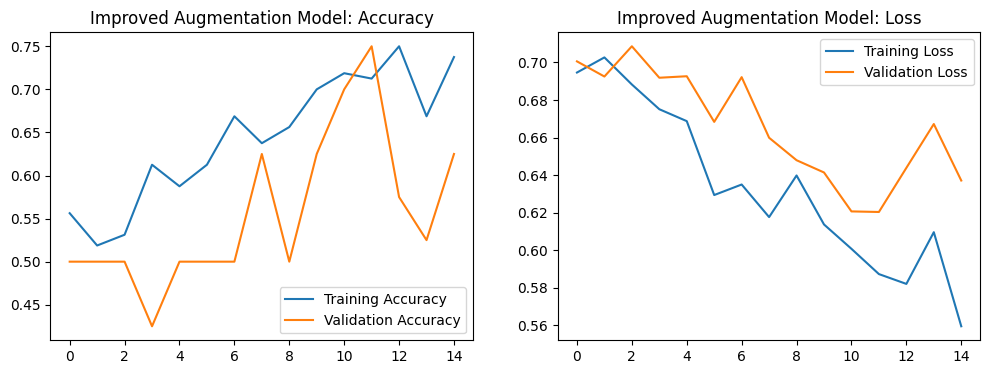

In [8]:
# Strategy 1: More Augmentation
print("Training Improved Model (More Augmentation)...")

improved_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, # Increased
    width_shift_range=0.1, # Added
    height_shift_range=0.1, # Added
    zoom_range=0.2, # Added
    brightness_range=[0.8, 1.2], # Added
    horizontal_flip=True,
    validation_split=0.2
)

improved_train_generator = improved_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Re-use same model architecture for fair comparison, just retrain
model_aug = build_baseline_model()
history_aug = model_aug.fit(
    improved_train_generator,
    validation_data=validation_generator, # Keep validation set same/simple for comparison
    epochs=EPOCHS
)

plot_history(history_aug, title="Improved Augmentation Model")

## 9. Model Improvement Strategy 2: Deeper Architecture

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,289 (1.48 MB)

 Trainable params: 388,289 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 539ms/step - accuracy: 0.5437 - loss: 0.7040 - precision: 0.5556 - recall: 0.4375 - val_accuracy: 0.5000 - val_loss: 0.7040 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step - accuracy: 0.4688 - loss: 0.7051 - precision: 0.4627 - recall: 0.3875 - val_accuracy: 0.5250 - val_loss: 0.6934 - val_precision: 1.0000 - val_recall: 0.0500
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 0.5000 - loss: 0.6969 - precision: 0.5000 - recall: 0.7875 - val_accuracy: 0.5000 - val_loss: 0.6948 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 0.5375 - loss: 0.6920 - precision: 0.5221 - recall: 0.8875 - val_accuracy: 0.5000 - val_loss: 0.6920 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 428ms/step - accuracy: 0.5875 - loss: 0.6861 - precision: 0.5515 - recall: 0.9375 - val_accuracy: 0.5000 - val_loss: 0.6912 - val

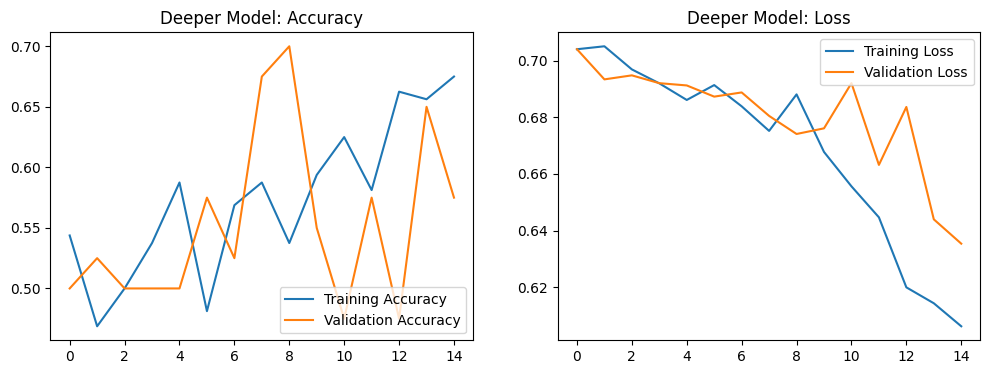

In [9]:
def build_deeper_model():
    model = Sequential([
        # First Conv Block
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        MaxPooling2D(2, 2),
        
        # Second Conv Block
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Third Conv Block (Added)
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Flatten and Dense
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
    return model

model_deeper = build_deeper_model()
model_deeper.summary()

history_deeper = model_deeper.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

plot_history(history_deeper, title="Deeper Model")

## 10. Comparative Analysis

In [10]:
# Compare Accuracies
base_acc = history_baseline.history['val_accuracy'][-1]
aug_acc = history_aug.history['val_accuracy'][-1]
deeper_acc = history_deeper.history['val_accuracy'][-1]

print(f"{'Model':<30} | {'Validation Accuracy':<20}")
print("-" * 55)
print(f"{'Baseline Model':<30} | {base_acc*100:.2f}%")
print(f"{'Augmented Model':<30} | {aug_acc*100:.2f}%")
print(f"{'Deeper Model':<30} | {deeper_acc*100:.2f}%")

# Simple analysis
best_model_acc = max(base_acc, aug_acc, deeper_acc)
if best_model_acc == base_acc:
    print("\nConclusion: The Baseline model performed best.")
elif best_model_acc == aug_acc:
    print("\nConclusion: Data Augmentation improved the model performance.")
else:
    print("\nConclusion: Increasing model depth improved the model performance.")

Model                          | Validation Accuracy 
-------------------------------------------------------
Baseline Model                 | 67.50%
Augmented Model                | 62.50%
Deeper Model                   | 57.50%

Conclusion: The Baseline model performed best.
